# 02. Pre-process 14k Jester Subsample 

**Objective:** Generate 80/10/10 train/val/test splits from the 14k subsample obtained in 01_generate_14k_subsample.ipynb and pre-process for ML model input.

**Instructions:**

1. Load in the saved 14k subsample of Jester videos generated from 01_generate_14k_subsample.ipynb
2. Run the notebook cell-by-cell

**Data source reference:**

 * Sanjana T G. (2025). 20bn-jester-v1-complete (Version 1) [Data set]. Kaggle. https://www.kaggle.com/datasets/sanjanatg26/20bn-jester-v1-complete/data

**Github links to jester labels**:

* [Link](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-train.csv) to train labels. 
* [Link](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-validation.csv) to validation labels.
* [Link](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-test.csv) to test .csv.

**Pre-processing Steps:**

1. Read in the subsample of 14k videos generated from **01_generate_14k_subsample.ipynb**
2. Then split the 14,000 videos this into 80/10/10 train/val/test:
    * Train: 11,200 (800 per class)
    * Val: 1,400 (100 per class)
    * Test: 1,400 (100 per class)
    * Save out the mappings 
3. Pre-process train/val/test separately 
    * Re-size to 299x299 for Inception backbone
4. Extract hand keypoints to be cached as PyTorch tensors:
    * Documentation: https://mediapipe.readthedocs.io/en/latest/solutions/hands.html
    * Reference: https://www.kaggle.com/code/praneeth0210/mediapipe-hands-jester/notebook



# 1. Read in subsampled data (Obtained this from the prepare_dataset.ipynb) as DataFrame




In [ ]:
# Imports 
import os 
import io
import csv
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import pandas as pd

import matplotlib.pyplot as plt

# ==============================
# Load Data 
# ==============================

# Read in the subsampled data from ./jester_uncompressed 
metadata_path = "./jester-v1/jester_uncompressed/jester-v1-train.csv"
print("Loading and filtering dataset...")
df = pd.read_csv(metadata_path, sep=';', header=None, names=['video_id', 'gesture'])

target_classes = [
    "Swiping Left", "Swiping Right", "Swiping Up", "Swiping Down",
    "Sliding Two Fingers Up", "Sliding Two Fingers Down", "Sliding Two Fingers Left", "Sliding Two Fingers Right",
    "Zooming In With Two Fingers", "Zooming Out With Two Fingers",
    "Drumming Fingers", "Pushing Two Fingers Away",
    "No gesture", "Doing other things"
]

clean_df = df[df['gesture'].isin(target_classes)].reset_index(drop=True)
clean_df = clean_df.groupby('gesture').head(1000).reset_index(drop=True)

# Safely auto-locate the extracted videos directory using a REAL video ID
sample_video_id = str(clean_df.iloc[0]['video_id'])
dataset_path = None
for root, dirs, files in os.walk('./jester-v1/jester_uncompressed'):
    if sample_video_id in dirs:
        dataset_path = root
        break

if not dataset_path:
    raise FileNotFoundError(f"Could not locate the folder containing video {sample_video_id}. Cell 1 may not have extracted correctly.")
print(f"Successfully locked onto extracted videos at: {dataset_path}")

all_labels = sorted(clean_df['gesture'].unique())
label_map = {label: idx for idx, label in enumerate(all_labels)}
print(f"Total UI Classes Locked: {len(label_map)}")

Loading and filtering dataset...
Successfully locked onto extracted videos at: ./jester-v1/jester_uncompressed/20bn-jester-v1
Total UI Classes Locked: 14


   video_id                       gesture
0     34870              Drumming Fingers
1     56557     Sliding Two Fingers Right
2    129112      Sliding Two Fingers Down
3    131717        Sliding Two Fingers Up
4     23595  Zooming Out With Two Fingers
5     68574                 Swiping Right
6    119263   Zooming In With Two Fingers
7    118480            Doing other things
8      6522                  Swiping Down
9     20706                    No gesture
(14000, 2)


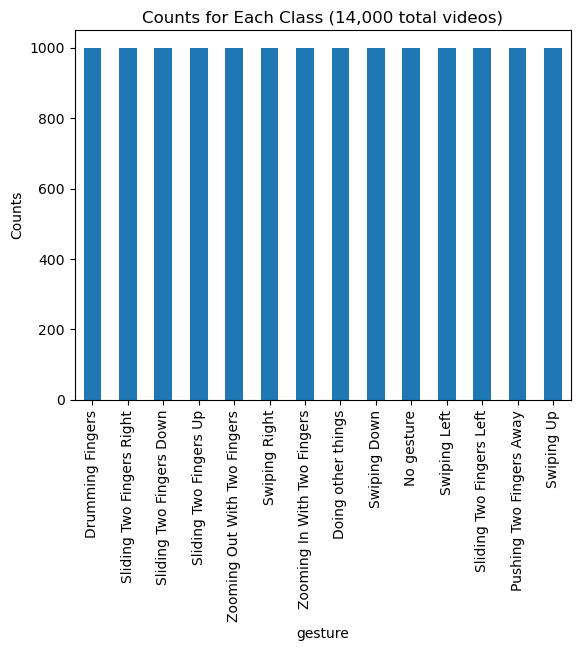

In [2]:
# Checking df
print(clean_df.head(10))
from dataset_utils.JesterUIDataset import JesterUIDataset
print(clean_df.shape)

# Get counts for each class - verify there are 1000 for each class 
plt.title("Counts for Each Class (14,000 total videos)")
plt.ylabel('Counts')
clean_df["gesture"].value_counts().plot(kind="bar")
plt.show()

## 2. Split clean_df into train/val/test

* splits clean_df into train/val/test with stratification
* Save CSVs listing video_id + gesture for each split

In [ ]:
from sklearn.model_selection import train_test_split
import shutil

# Train/val/test splits
train_frac = 0.80
val_frac = 0.10
test_frac = 0.10

# 2. Split train vs temp (val+test)
train_df, temp_df = train_test_split(
    clean_df,
    test_size=(1 - train_frac),
    stratify=clean_df['gesture'],
    random_state=42
)

# 3. Split temp into val and test with same class balance
val_size = val_frac / (val_frac + test_frac)
val_df, test_df = train_test_split(
    temp_df,
    test_size=(1 - val_size),
    stratify=temp_df['gesture'],
    random_state=42
)
# 4. Check counts for each 
print("\nCounts per split (train):")
print(train_df['gesture'].value_counts().sort_index())
print("\nCounts per split (val):")
print(val_df['gesture'].value_counts().sort_index())
print("\nCounts per split (test):")
print(test_df['gesture'].value_counts().sort_index())

# Save out the splits and their mappings 
out_dir = "./jester-v1/jester_uncompressed/jester_splits"
os.makedirs(out_dir, exist_ok=True)

train_df.to_csv(os.path.join(out_dir, "train.csv"), index=False)
val_df.to_csv(os.path.join(out_dir, "val.csv"), index=False)
test_df.to_csv(os.path.join(out_dir, "test.csv"), index=False)
print(f"\nSaved train/val/test splits to {out_dir}")


Counts per split (train):
gesture
Doing other things              800
Drumming Fingers                800
No gesture                      800
Pushing Two Fingers Away        800
Sliding Two Fingers Down        800
Sliding Two Fingers Left        800
Sliding Two Fingers Right       800
Sliding Two Fingers Up          800
Swiping Down                    800
Swiping Left                    800
Swiping Right                   800
Swiping Up                      800
Zooming In With Two Fingers     800
Zooming Out With Two Fingers    800
Name: count, dtype: int64

Counts per split (val):
gesture
Doing other things              100
Drumming Fingers                100
No gesture                      100
Pushing Two Fingers Away        100
Sliding Two Fingers Down        100
Sliding Two Fingers Left        100
Sliding Two Fingers Right       100
Sliding Two Fingers Up          100
Swiping Down                    100
Swiping Left                    100
Swiping Right                   100
Swipin

### Verify Class Balance 

n\ train_df first few records...


,video_id,gesture
0,92681,Sliding Two Fingers Left
1,95377,Zooming In With Two Fingers
2,72589,Sliding Two Fingers Right
3,114418,Sliding Two Fingers Down
4,58439,Swiping Up


n\ val_df first few records...


,video_id,gesture
0,53648,Drumming Fingers
1,124251,Drumming Fingers
2,49376,Sliding Two Fingers Left
3,25925,Swiping Up
4,122039,Drumming Fingers


n\ test_df first few records...


,video_id,gesture
0,37086,Pushing Two Fingers Away
1,138155,No gesture
2,5531,Sliding Two Fingers Down
3,112714,Swiping Down
4,59576,Swiping Left


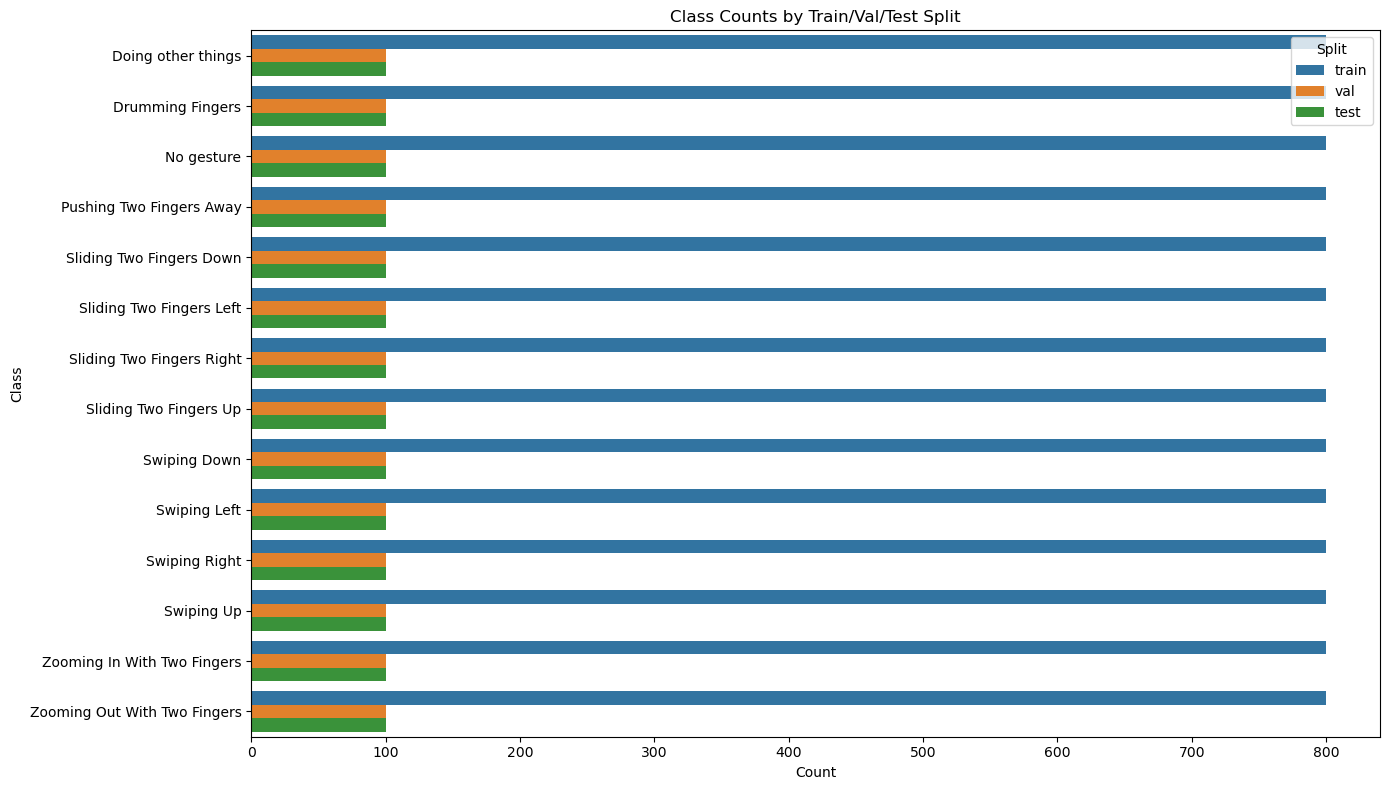

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load in the train/val/test .csv labels 
splits_dir = "./jester-v1/jester_uncompressed/jester_splits"
train_csv = os.path.join(splits_dir, "train.csv")
val_csv   = os.path.join(splits_dir, "val.csv")
test_csv  = os.path.join(splits_dir, "test.csv")

# Load in splits as DataFrames 
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print("n\ train_df first few records...")
display(train_df.head())
print("n\ val_df first few records...")
display(val_df.head())
print("n\ test_df first few records...")
display(test_df.head())

# Order classes consistently
classes = sorted(pd.concat([train_df['gesture'], val_df['gesture'], test_df['gesture']]).unique())

# Count per class
train_counts = train_df['gesture'].value_counts().reindex(classes, fill_value=0)
val_counts   = val_df['gesture'].value_counts().reindex(classes, fill_value=0)
test_counts  = test_df['gesture'].value_counts().reindex(classes, fill_value=0)

# Grouped df to check the counts for each class for each split
counts_df = pd.DataFrame({
    'class': classes,
    'train': train_counts.values,
    'val': val_counts.values,
    'test': test_counts.values
}).melt(id_vars='class', var_name='split', value_name='count')

plt.figure(figsize=(14,8))
sns.barplot(data=counts_df, x='count', y='class', hue='split')
plt.title("Class Counts by Train/Val/Test Split")
plt.xlabel("Count")
plt.ylabel("Class")
plt.legend(title='Split')
plt.tight_layout()
plt.show()

## 4. Pre-process train/val/test separately (TO-DO)

* Re-size to 299x299 for Inception backbone

In [ ]:
# Reference: 
# Kaggle author: PEACE AKHAZE 
# Kaggle notebook link: https://www.kaggle.com/code/peaceakhaze/notebook53b831d07d

# Reference: 
# class JesterUIDataset(Dataset):
#     def __init__(self, dataframe, root_dir, transform=None, label_map=None, num_frames=16):
#         self.dataframe = dataframe.reset_index(drop=True)
#         self.root_dir = root_dir
#         self.transform = transform
#         self.label_map = label_map
#         self.num_frames = num_frames

#         if self.label_map is None:
#             raise ValueError("label_map must be provided to prevent class mismatch.")

#     def __len__(self):
#         return len(self.dataframe)

#     def _sample_frame_indices(self, num_available):
#         if num_available <= self.num_frames:
#             return list(range(num_available)) + [num_available - 1] * (self.num_frames - num_available)
#         return np.linspace(0, num_available - 1, num=self.num_frames).astype(int).tolist()

#     def __getitem__(self, idx):
#         row = self.dataframe.iloc[idx]
#         video_id = str(row['video_id'])
#         label_idx = torch.tensor(self.label_map[row['gesture']], dtype=torch.long)

#         video_path = os.path.join(self.root_dir, video_id)
#         if not os.path.exists(video_path):
#             return torch.zeros((self.num_frames, 3, INCEPTION_SIZE, INCEPTION_SIZE)), label_idx

#         frame_files = sorted([f for f in os.listdir(video_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
#         if len(frame_files) == 0:
#             return torch.zeros((self.num_frames, 3, INCEPTION_SIZE, INCEPTION_SIZE)), label_idx

#         # Uniform frame sampling
#         indices = self._sample_frame_indices(len(frame_files))
#         frames = []
#         for i in indices:
#             img_path = os.path.join(video_path, frame_files[i])
#             try:
#                 with Image.open(img_path) as img:
#                     img = img.convert('RGB')
#                     img = self.transform(img) if self.transform else transforms.ToTensor()(img)
#                     frames.append(img)
#             except Exception:
#                 frames.append(torch.zeros((3, INCEPTION_SIZE, INCEPTION_SIZE)))
                
#          # Stack into (num_frames, 3, H, W)
#         video_tensor = torch.stack(frames)  # (N,3,H,W)
#         return video_tensor, label_idx


In [ ]:
# Reference: 
# Kaggle author: PEACE AKHAZE 
# Kaggle notebook link: https://www.kaggle.com/code/peaceakhaze/notebook53b831d07d

# from dataset_utils.JesterUIDataset import JesterUIDataset
# from torchvision import transforms
# from torch.utils.data import DataLoader

# # Define Input Size and Normalization required for pre-trained InceptionV3

# inception_size = 299
# imagenet_mean = [0.485, 0.456, 0.406]
# imagenet_std  = [0.229, 0.224, 0.225]

# # 3. Data Transformations & DataLoader
# # ==============================
# transform = transforms.Compose([
#     transforms.Resize((inception_size, inception_size)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
# ])

# train_dataset = JesterUIDataset(train_df, root_dir=dataset_path, transform=eval_transform, label_map=label_map, num_frames=16)
# val_dataset   = JesterUIDataset(val_df,   root_dir=dataset_path, transform=eval_transform, label_map=label_map, num_frames=16)
# test_dataset  = JesterUIDataset(test_df,  root_dir=dataset_path, transform=eval_transform, label_map=label_map, num_frames=16)

# train_loader = DataLoader(train_dataset, batch_size=8, shuffle=False, num_workers=4, pin_memory=True)